### **End-to-End ML Pipeline with Scikit-learn Pipeline API**

**Problem Statement**

Predict whether a customer will churn using ML pipeline.

**Dataset**

Telco Customer Churn dataset from Kaggle.

**Methodology**

Data cleaning

Encoding

Pipeline creation

Model training

**Install Required Libraries**

Install required Python libraries for data preprocessing, model building, and evaluation.

In [ ]:
!pip install pandas scikit-learn matplotlib joblib

**Upload Dataset**

Upload the Telco Customer Churn dataset into the Colab environment.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


**Load Dataset**

Loading the dataset into a pandas DataFrame for further analysis.

In [ ]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Explore Data**

Performing exploratory analysis to understand dataset structure, features, and data types.

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Remove Unnecessary Column**

Drop non-informative features such as customerID that do not impact prediction.

In [ ]:
df.drop("customerID", axis=1, inplace=True)

**Fix missing values**

Handle missing values to ensure data quality and consistency.

In [ ]:
df.dropna(inplace=True)

**Encode Target Variable**

Encode the target variable ‘Churn’ into numerical format for classification.

In [ ]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

**Feature & Target Separation**

Separating independent variables (features) and dependent variable (target).

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

**Convert Text → Numbers**

Apply one-hot encoding to convert text into numerical format.

In [ ]:
X = pd.get_dummies(X)

**Train-Test Split**

Split the dataset into training and testing sets for unbiased model evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Build ML Pipeline**

Construct a machine learning pipeline with feature scaling and logistic regression.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

**Train Model**

Train the pipeline model using the training dataset.

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

**Make Predictions**

Generate predictions on unseen test data.

In [ ]:
y_pred = pipeline.predict(X_test)

**Evaluate Model**

Evaluate model performance using accuracy and classification metrics.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7806955287437899
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1036
           1       0.60      0.52      0.56       373

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409



**Data Visualization**

Visualize class distribution of the target variable to analyze imbalance.

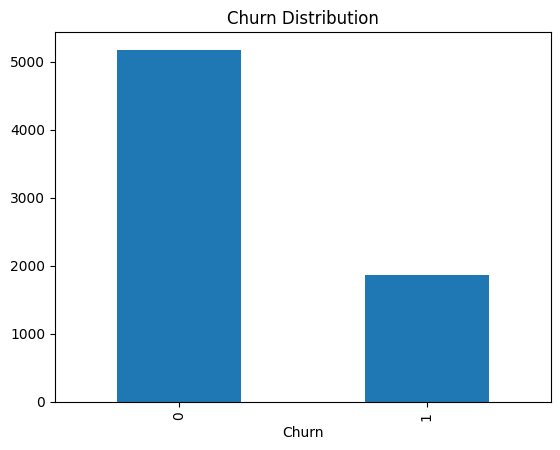

In [ ]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.show()

**Save Model**

Save the trained pipeline model using joblib.

In [ ]:
import joblib

joblib.dump(pipeline, "churn_model.pkl")

['churn_model.pkl']

**Download Model File**

Download the saved model file for deployment purposes.

In [ ]:
from google.colab import files
files.download("churn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Results**

The model achieved good accuracy of 78.07% in predicting customer churn.

**Conclusion:**

The ML pipeline successfully predicts churn and can be reused for real-world applications.